In [1]:
%load_ext autoreload
%autoreload 2

In [1]:
import stim 
import random
from stim_baconshor import *
import sinter
import matplotlib.pyplot as plt
from scipy.stats import linregress

In [2]:
circuit = bacon_shor_circuit(5,0.6)

In [7]:
circuit

stim.Circuit('''
    QUBIT_COORDS(0, 0, 0) 0
    QUBIT_COORDS(1, 0, 0) 1
    QUBIT_COORDS(2, 0, 0) 2
    QUBIT_COORDS(3, 0, 0) 3
    QUBIT_COORDS(4, 0, 0) 4
    QUBIT_COORDS(0, 1, 0) 5
    QUBIT_COORDS(1, 1, 0) 6
    QUBIT_COORDS(2, 1, 0) 7
    QUBIT_COORDS(3, 1, 0) 8
    QUBIT_COORDS(4, 1, 0) 9
    QUBIT_COORDS(0, 2, 0) 10
    QUBIT_COORDS(1, 2, 0) 11
    QUBIT_COORDS(2, 2, 0) 12
    QUBIT_COORDS(3, 2, 0) 13
    QUBIT_COORDS(4, 2, 0) 14
    QUBIT_COORDS(0, 3, 0) 15
    QUBIT_COORDS(1, 3, 0) 16
    QUBIT_COORDS(2, 3, 0) 17
    QUBIT_COORDS(3, 3, 0) 18
    QUBIT_COORDS(4, 3, 0) 19
    QUBIT_COORDS(0, 4, 0) 20
    QUBIT_COORDS(1, 4, 0) 21
    QUBIT_COORDS(2, 4, 0) 22
    QUBIT_COORDS(3, 4, 0) 23
    QUBIT_COORDS(4, 4, 0) 24
    TICK
    MZZ 0 5 1 6 2 7 3 8 4 9
    TICK
    MZZ 5 10 6 11 7 12 8 13 9 14
    TICK
    MZZ 10 15 11 16 12 17 13 18 14 19
    TICK
    MZZ 15 20 16 21 17 22 18 23 19 24
    TICK
    MXX 0 1 5 6 10 11 15 16 20 21
    TICK
    MXX 1 2 6 7 11 12 16 17 21 22
    TICK


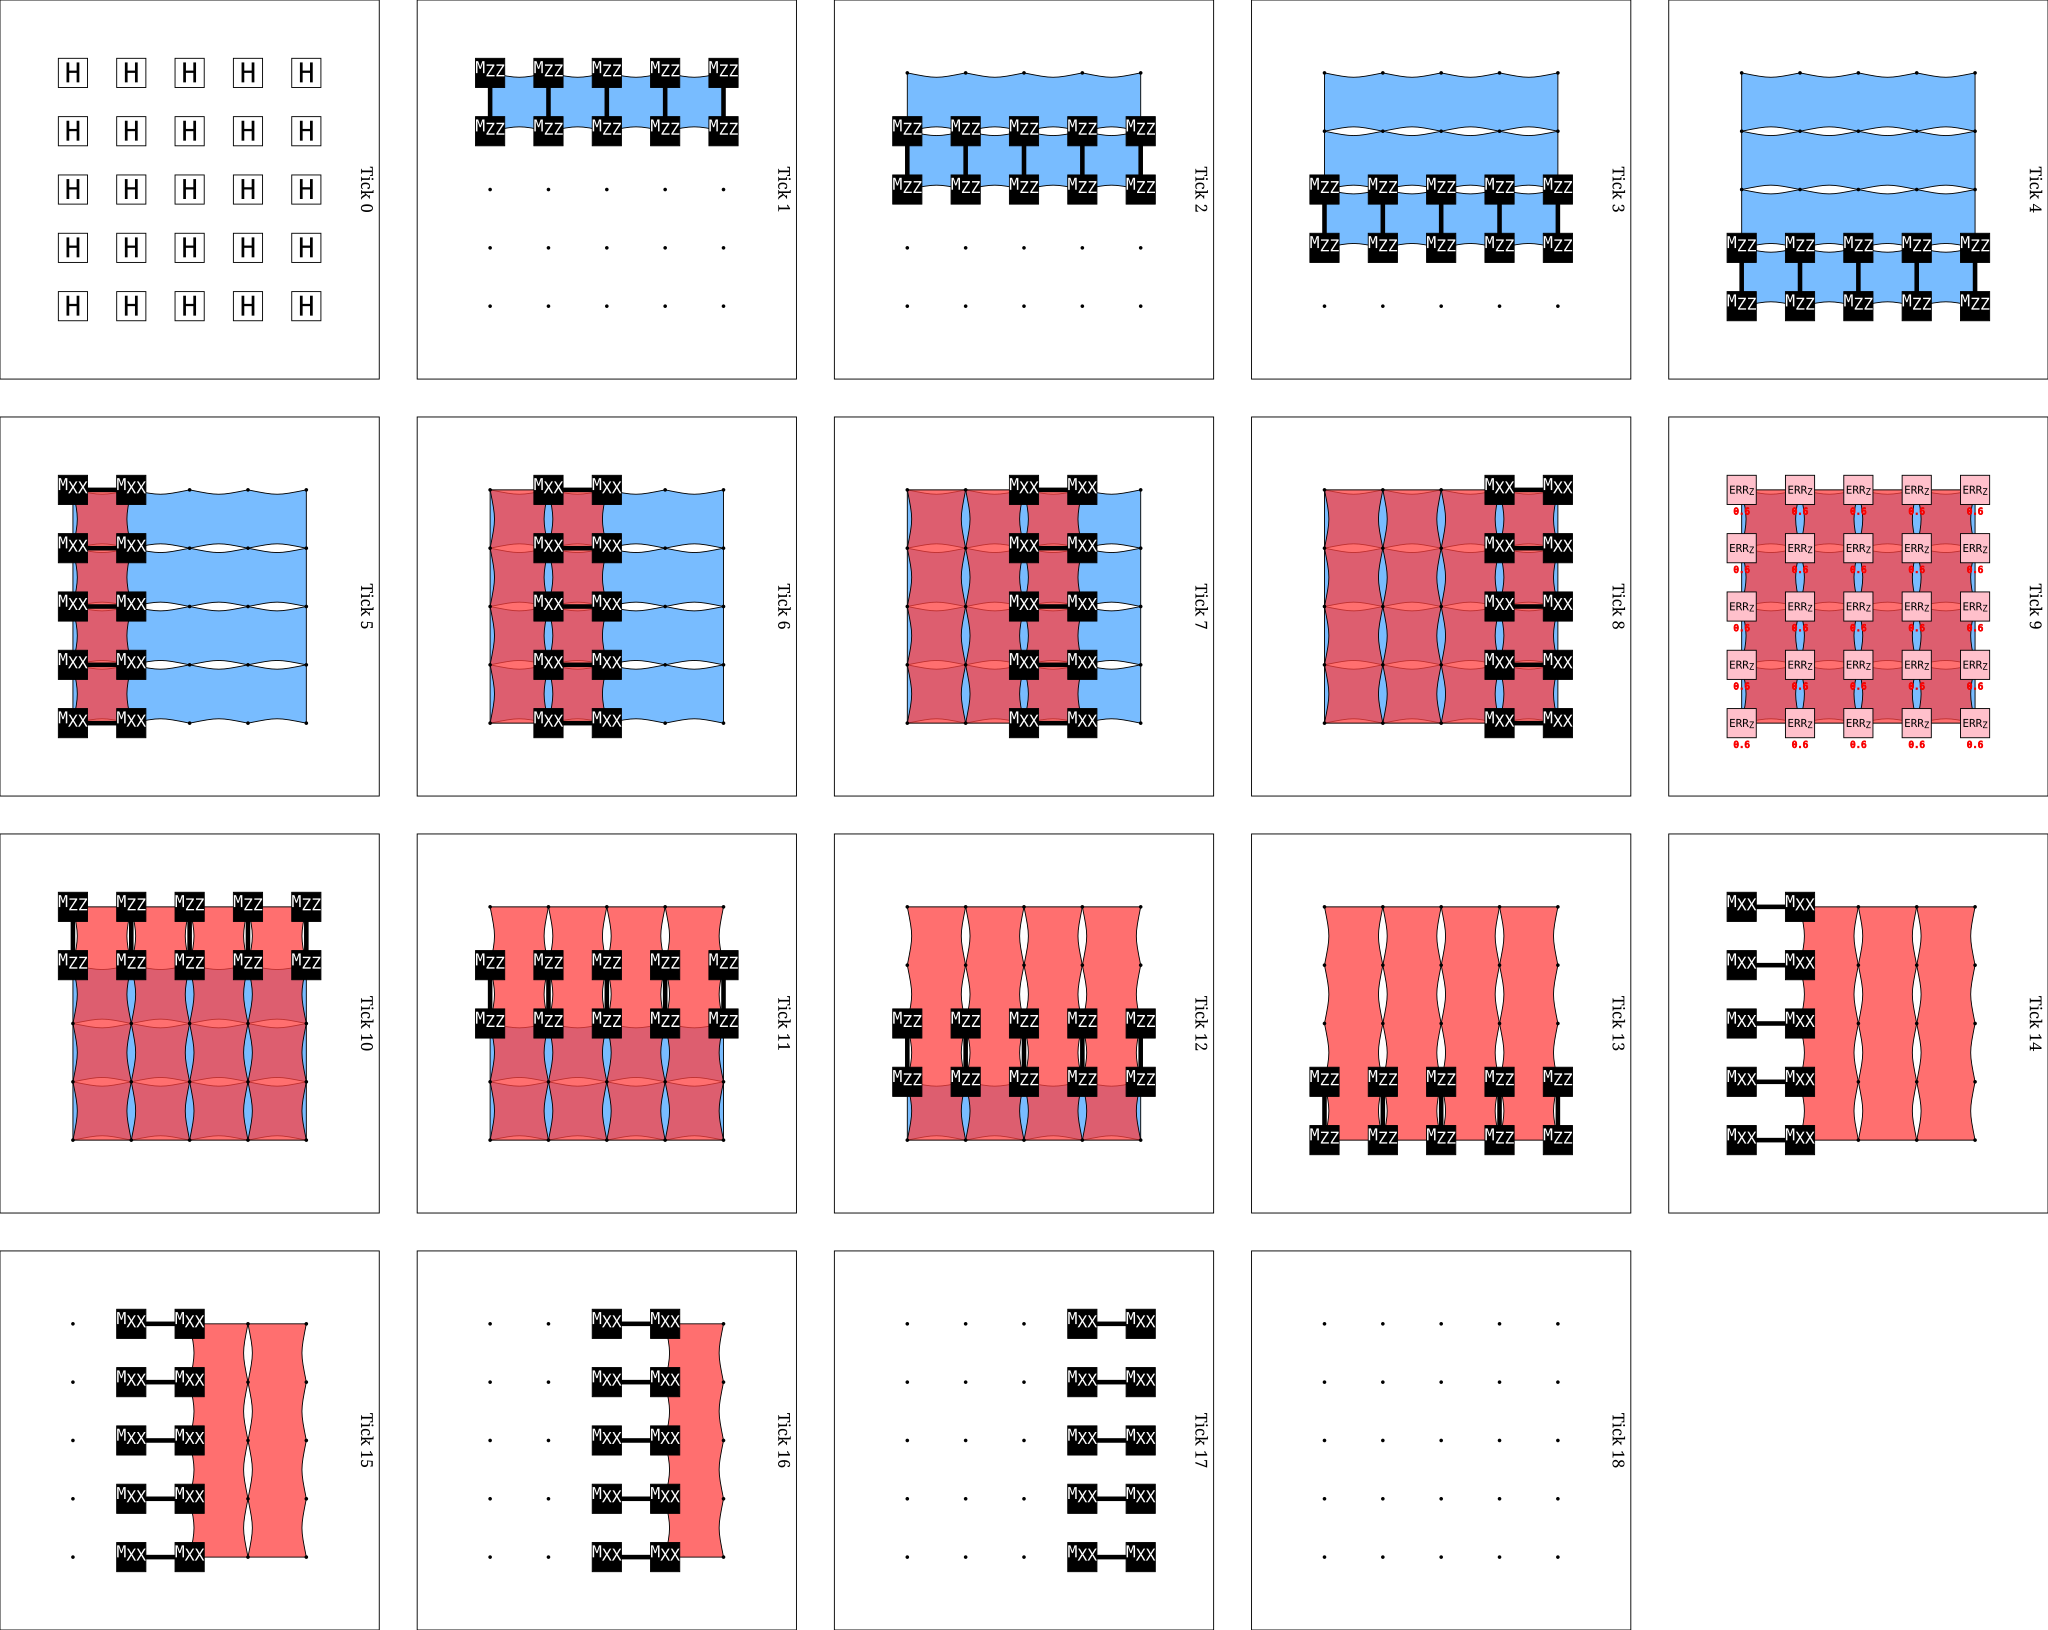

In [3]:
circuit.diagram("detslice-with-ops-svg")

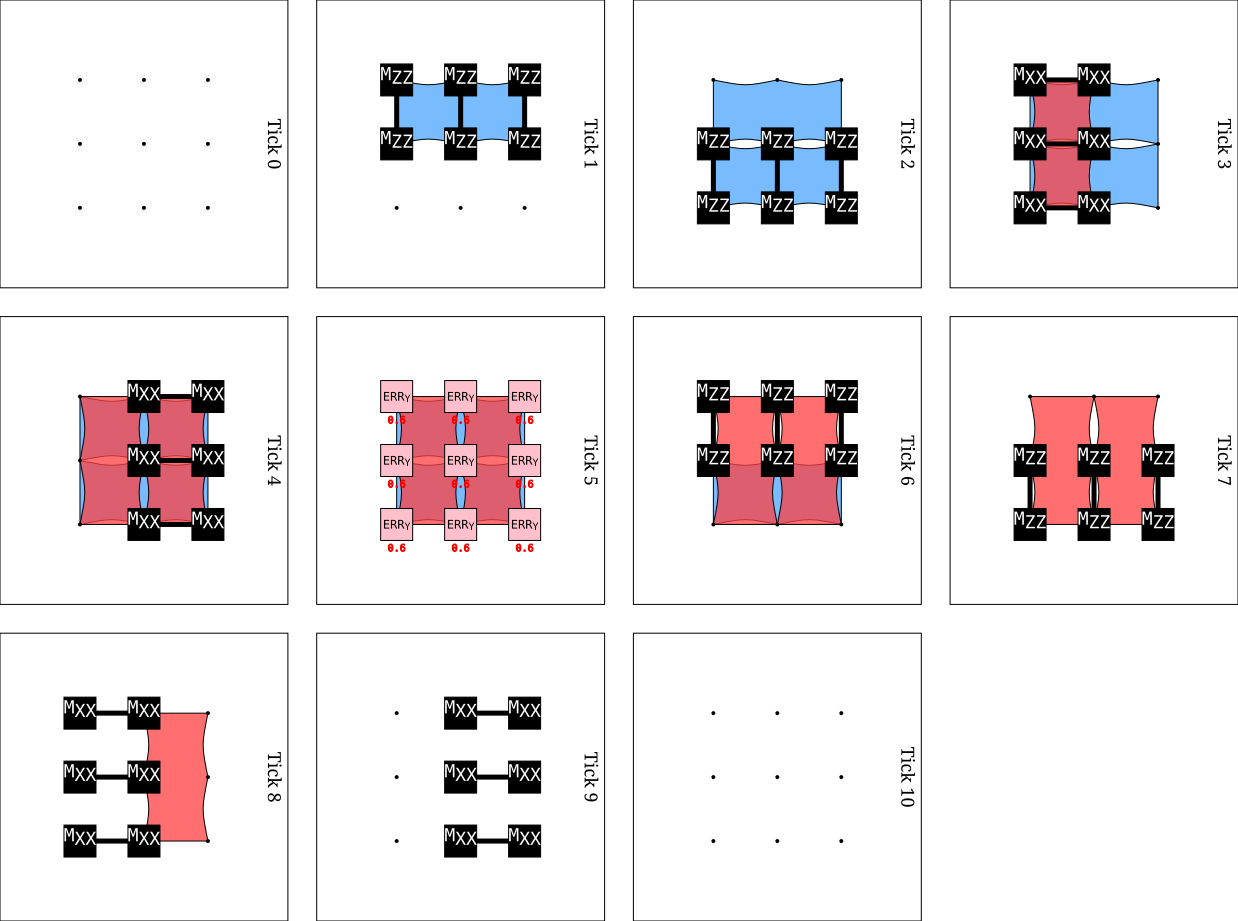

In [5]:
circuit.diagram("detslice-with-ops-svg")

## Only Y error

In [2]:
ps = np.logspace(np.log10(0.001), np.log10(0.04), 50)
tasks = [
    sinter.Task(
        circuit=bacon_shor_circuit(d=7, p=p),
        json_metadata={'p': p, 'd': 7}
    )
    for p in ps
]

# Run the collection
stats = sinter.collect(
    num_workers=4,
    tasks=tasks,
    decoders=['pymatching'],
    max_shots=100_000,
    max_errors=100,
)

RuntimeError: Worker failed: traceback=Traceback (most recent call last):
  File "/opt/anaconda3/envs/qec_env/lib/python3.11/site-packages/sinter/_collection/_collection_worker_state.py", line 246, in run_message_loop
    did_some_work = self.do_some_work()
                    ^^^^^^^^^^^^^^^^^^^
  File "/opt/anaconda3/envs/qec_env/lib/python3.11/site-packages/sinter/_collection/_collection_worker_state.py", line 217, in do_some_work
    some_work_done = self.compiled_sampler.sample(self.current_task_shots_left)
                     ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/opt/anaconda3/envs/qec_env/lib/python3.11/site-packages/sinter/_collection/_sampler_ramp_throttled.py", line 51, in sample
    result = self.sub_sampler.sample(actual_shots)
             ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/opt/anaconda3/envs/qec_env/lib/python3.11/site-packages/sinter/_decoding/_stim_then_decode_sampler.py", line 193, in sample
    predictions = self.compiled_dec

## X error

In [15]:
circuit = bacon_shor_circuit(5,0.6)

p=0.0010781895093053744, errors=1, rate=1e-05
p=0.0011624926179761637, errors=4, rate=4e-05
p=0.00125338734534684, errors=6, rate=6e-05
p=0.001, errors=3, rate=3e-05
p=0.0015709798374755985, errors=9, rate=9e-05
p=0.001457053536430442, errors=8, rate=8e-05
p=0.0016938139800964523, errors=5, rate=5e-05
p=0.001351389086849075, errors=4, rate=4e-05
p=0.0021230050080244573, errors=9, rate=9e-05
p=0.0019690462480869506, errors=12, rate=0.00012
p=0.0018262524640547768, errors=8, rate=8e-05
p=0.002289001727854742, errors=12, rate=0.00012
p=0.002467977649754858, errors=11, rate=0.00011
p=0.0028690057991701875, errors=31, rate=0.00031
p=0.002660947611165824, errors=19, rate=0.00019
p=0.0030933319548015776, errors=27, rate=0.00027
p=0.0033351980624661474, errors=29, rate=0.00029
p=0.004180295045720368, errors=49, rate=0.00049
p=0.0035959755624066104, errors=35, rate=0.00035
p=0.0038771431271053007, errors=46, rate=0.00046
p=0.004859562131612258, errors=74, rate=0.00074
p=0.004507150264096931, er

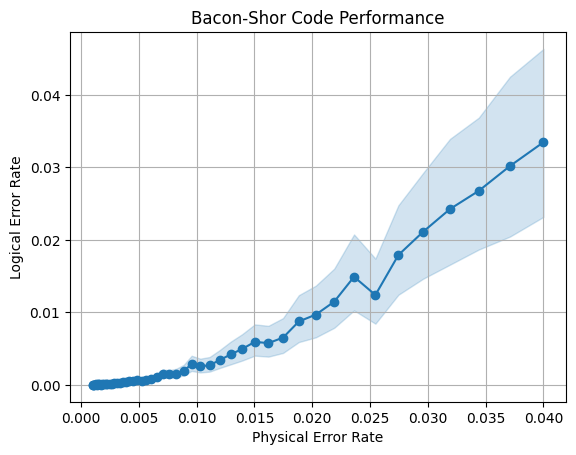

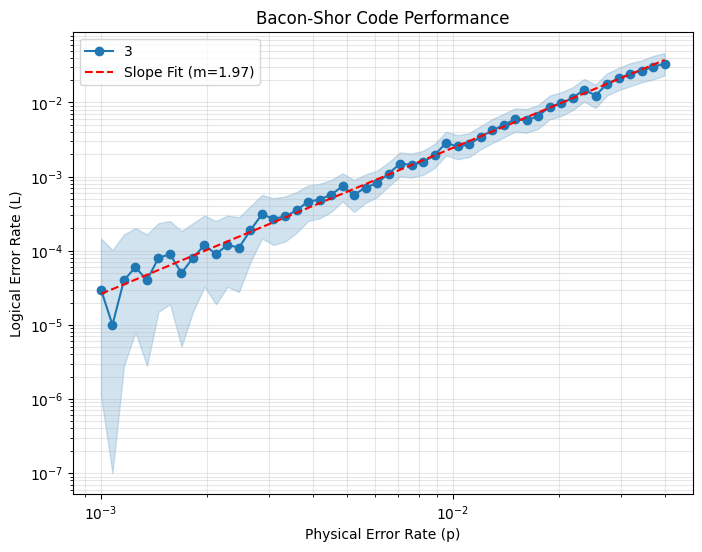

Calculated Slope: 1.9698


In [2]:
ps = np.logspace(np.log10(0.001), np.log10(0.04), 50)
tasks = [
    sinter.Task(
        circuit=bacon_shor_circuit(d=3, p=p),
        json_metadata={'p': p, 'd': 3}
    )
    for p in ps
]

# Run the collection
stats = sinter.collect(
    num_workers=4,
    tasks=tasks,
    decoders=['pymatching'],
    max_shots=100_000,
    max_errors=100,
)
for stat in stats:
    print(f"p={stat.json_metadata['p']}, errors={stat.errors}, rate={stat.errors/stat.shots}")

fig, ax = plt.subplots(1, 1)
sinter.plot_error_rate(
    ax=ax,
    stats=stats,
    x_func=lambda stat: stat.json_metadata['p'],
    group_func=lambda stat: stat.json_metadata['d'],
)
ax.set_title("Bacon-Shor Code Performance")
ax.set_xlabel("Physical Error Rate")
ax.set_ylabel("Logical Error Rate")
ax.grid(True)
plt.show()

xs = np.array([s.json_metadata['p'] for s in stats])
ys = np.array([s.errors / s.shots for s in stats])

# Filter out points with 0 errors (log doesn't like zero)
mask = (ys > 0)
log_p = np.log10(xs[mask])
log_L = np.log10(ys[mask])

# Linear regression: log(L) = slope * log(p) + intercept
slope, intercept, r_value, _, _ = linregress(log_p, log_L)

# --- 4. Plotting ---
fig, ax = plt.subplots(1, 1, figsize=(8, 6))

# Use sinter's plotter for the points
sinter.plot_error_rate(
    ax=ax,
    stats=stats,
    x_func=lambda s: s.json_metadata['p'],
    group_func=lambda s: s.json_metadata['d'],
)

# Plot the fitted slope line
fit_x = np.linspace(min(xs[mask]), max(xs[mask]), 100)
fit_y = 10**(slope * np.log10(fit_x) + intercept)
ax.plot(fit_x, fit_y, 'r--', label=f'Slope Fit (m={slope:.2f})')

ax.set_title("Bacon-Shor Code Performance")
ax.set_xlabel("Physical Error Rate (p)")
ax.set_ylabel("Logical Error Rate (L)")
ax.set_xscale('log')
ax.set_yscale('log')
ax.legend()
ax.grid(True, which="both", ls="-", alpha=0.3)
plt.show()

print(f"Calculated Slope: {slope:.4f}")

## High d with y error and small z

p=0.0010781895093053744, errors=101, rate=0.0010926833490203715
p=0.0011624926179761637, errors=100, rate=0.001093984180988743
p=0.00125338734534684, errors=101, rate=0.0010689979995978027
p=0.001, errors=100, rate=0.001004005983875664
p=0.0015709798374755985, errors=100, rate=0.0017355988683895379
p=0.0016938139800964523, errors=103, rate=0.0016690162526534118
p=0.001457053536430442, errors=100, rate=0.0015435671837616732
p=0.001351389086849075, errors=101, rate=0.0012765258275299857
p=0.002289001727854742, errors=106, rate=0.0023925064891095814
p=0.0021230050080244573, errors=100, rate=0.002257081593499605
p=0.0019690462480869506, errors=102, rate=0.002063732928679818
p=0.0018262524640547768, errors=100, rate=0.0017670029862350467
p=0.0030933319548015776, errors=101, rate=0.0034893764035239245
p=0.002660947611165824, errors=103, rate=0.002699090694688294
p=0.0028690057991701875, errors=100, rate=0.002849895978796774
p=0.002467977649754858, errors=102, rate=0.002356692313024191
p=0.00

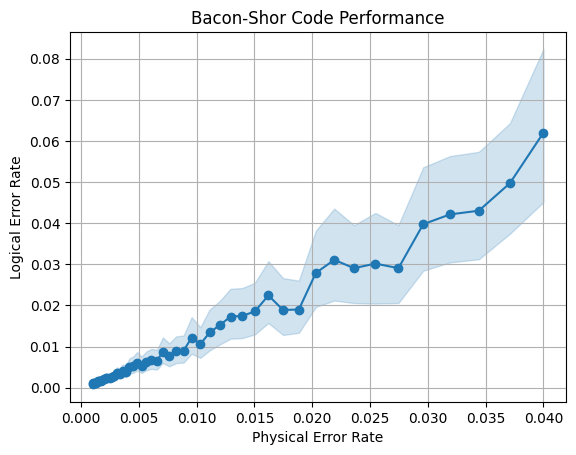

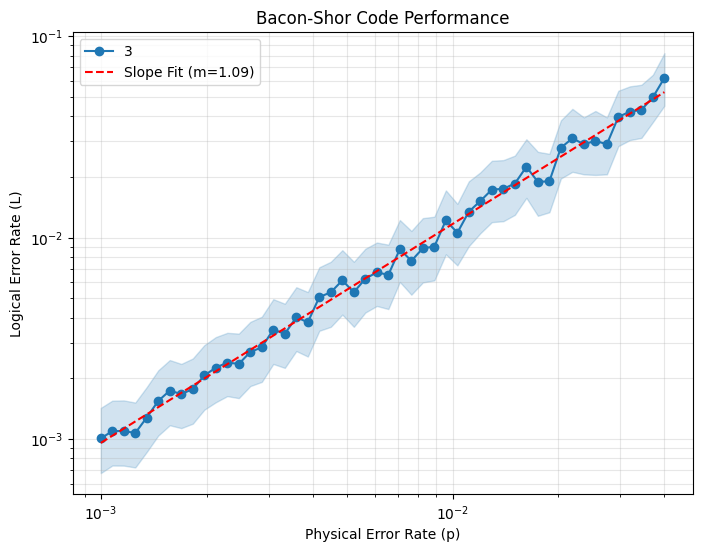

Calculated Slope: 1.0876


In [7]:
ps = np.logspace(np.log10(0.001), np.log10(0.04), 50)
tasks = [
    sinter.Task(
        circuit=bacon_shor_circuit(d=3, p=p),
        json_metadata={'p': p, 'd': 3}
    )
    for p in ps
]

# Run the collection
stats = sinter.collect(
    num_workers=4,
    tasks=tasks,
    decoders=['pymatching'],
    max_shots=100_000,
    max_errors=100,
)
for stat in stats:
    print(f"p={stat.json_metadata['p']}, errors={stat.errors}, rate={stat.errors/stat.shots}")

fig, ax = plt.subplots(1, 1)
sinter.plot_error_rate(
    ax=ax,
    stats=stats,
    x_func=lambda stat: stat.json_metadata['p'],
    group_func=lambda stat: stat.json_metadata['d'],
)
ax.set_title("Bacon-Shor Code Performance")
ax.set_xlabel("Physical Error Rate")
ax.set_ylabel("Logical Error Rate")
ax.grid(True)
plt.show()

xs = np.array([s.json_metadata['p'] for s in stats])
ys = np.array([s.errors / s.shots for s in stats])

# Filter out points with 0 errors (log doesn't like zero)
mask = (ys > 0)
log_p = np.log10(xs[mask])
log_L = np.log10(ys[mask])

# Linear regression: log(L) = slope * log(p) + intercept
slope, intercept, r_value, _, _ = linregress(log_p, log_L)

# --- 4. Plotting ---
fig, ax = plt.subplots(1, 1, figsize=(8, 6))

# Use sinter's plotter for the points
sinter.plot_error_rate(
    ax=ax,
    stats=stats,
    x_func=lambda s: s.json_metadata['p'],
    group_func=lambda s: s.json_metadata['d'],
)

# Plot the fitted slope line
fit_x = np.linspace(min(xs[mask]), max(xs[mask]), 100)
fit_y = 10**(slope * np.log10(fit_x) + intercept)
ax.plot(fit_x, fit_y, 'r--', label=f'Slope Fit (m={slope:.2f})')

ax.set_title("Bacon-Shor Code Performance")
ax.set_xlabel("Physical Error Rate (p)")
ax.set_ylabel("Logical Error Rate (L)")
ax.set_xscale('log')
ax.set_yscale('log')
ax.legend()
ax.grid(True, which="both", ls="-", alpha=0.3)
plt.show()

print(f"Calculated Slope: {slope:.4f}")

p=0.001, errors=6, rate=6e-05
p=0.0010781895093053744, errors=9, rate=9e-05
p=0.00125338734534684, errors=12, rate=0.00012
p=0.0011624926179761637, errors=8, rate=8e-05
p=0.001351389086849075, errors=8, rate=8e-05
p=0.001457053536430442, errors=10, rate=0.0001
p=0.0016938139800964523, errors=15, rate=0.00015
p=0.0015709798374755985, errors=17, rate=0.00017
p=0.0018262524640547768, errors=21, rate=0.00021
p=0.0019690462480869506, errors=16, rate=0.00016
p=0.002289001727854742, errors=34, rate=0.00034
p=0.0021230050080244573, errors=22, rate=0.00022
p=0.002467977649754858, errors=38, rate=0.00038
p=0.002660947611165824, errors=44, rate=0.00044
p=0.0028690057991701875, errors=50, rate=0.0005
p=0.0030933319548015776, errors=42, rate=0.00042
p=0.0033351980624661474, errors=68, rate=0.00068
p=0.0038771431271053007, errors=87, rate=0.00087
p=0.004180295045720368, errors=101, rate=0.0010245797701289347
p=0.0035959755624066104, errors=84, rate=0.00084
p=0.005239528910121999, errors=102, rate=0.

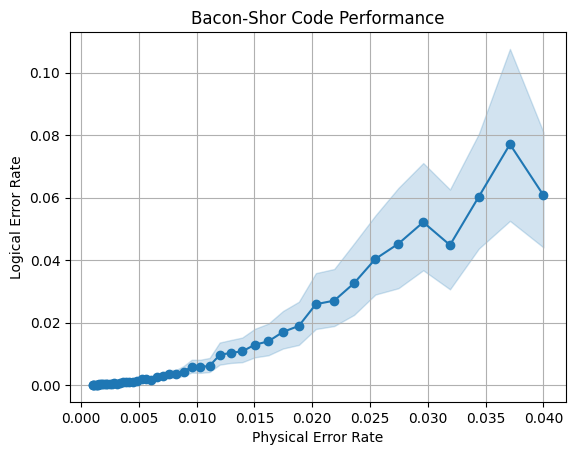

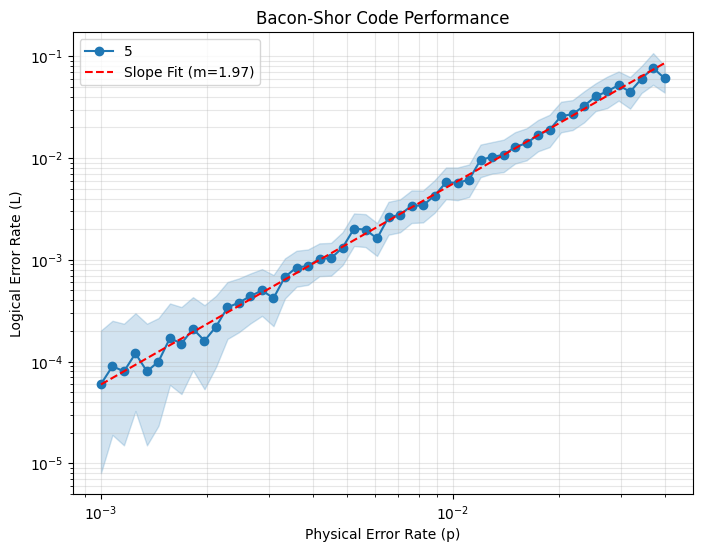

Calculated Slope: 1.9720


In [8]:
ps = np.logspace(np.log10(0.001), np.log10(0.04), 50)
tasks = [
    sinter.Task(
        circuit=bacon_shor_circuit(d=5, p=p),
        json_metadata={'p': p, 'd': 5}
    )
    for p in ps
]

# Run the collection
stats = sinter.collect(
    num_workers=4,
    tasks=tasks,
    decoders=['pymatching'],
    max_shots=100_000,
    max_errors=100,
)
for stat in stats:
    print(f"p={stat.json_metadata['p']}, errors={stat.errors}, rate={stat.errors/stat.shots}")

fig, ax = plt.subplots(1, 1)
sinter.plot_error_rate(
    ax=ax,
    stats=stats,
    x_func=lambda stat: stat.json_metadata['p'],
    group_func=lambda stat: stat.json_metadata['d'],
)
ax.set_title("Bacon-Shor Code Performance")
ax.set_xlabel("Physical Error Rate")
ax.set_ylabel("Logical Error Rate")
ax.grid(True)
plt.show()

xs = np.array([s.json_metadata['p'] for s in stats])
ys = np.array([s.errors / s.shots for s in stats])

# Filter out points with 0 errors (log doesn't like zero)
mask = (ys > 0)
log_p = np.log10(xs[mask])
log_L = np.log10(ys[mask])

# Linear regression: log(L) = slope * log(p) + intercept
slope, intercept, r_value, _, _ = linregress(log_p, log_L)

# --- 4. Plotting ---
fig, ax = plt.subplots(1, 1, figsize=(8, 6))

# Use sinter's plotter for the points
sinter.plot_error_rate(
    ax=ax,
    stats=stats,
    x_func=lambda s: s.json_metadata['p'],
    group_func=lambda s: s.json_metadata['d'],
)

# Plot the fitted slope line
fit_x = np.linspace(min(xs[mask]), max(xs[mask]), 100)
fit_y = 10**(slope * np.log10(fit_x) + intercept)
ax.plot(fit_x, fit_y, 'r--', label=f'Slope Fit (m={slope:.2f})')

ax.set_title("Bacon-Shor Code Performance")
ax.set_xlabel("Physical Error Rate (p)")
ax.set_ylabel("Logical Error Rate (L)")
ax.set_xscale('log')
ax.set_yscale('log')
ax.legend()
ax.grid(True, which="both", ls="-", alpha=0.3)
plt.show()

print(f"Calculated Slope: {slope:.4f}")

p=0.001, errors=0, rate=0.0
p=0.0011624926179761637, errors=0, rate=0.0
p=0.00125338734534684, errors=2, rate=2e-05
p=0.0010781895093053744, errors=0, rate=0.0
p=0.0016938139800964523, errors=0, rate=0.0
p=0.001351389086849075, errors=1, rate=1e-05
p=0.001457053536430442, errors=2, rate=2e-05
p=0.0015709798374755985, errors=1, rate=1e-05
p=0.0018262524640547768, errors=0, rate=0.0
p=0.0019690462480869506, errors=2, rate=2e-05
p=0.0021230050080244573, errors=4, rate=4e-05
p=0.002289001727854742, errors=5, rate=5e-05
p=0.002660947611165824, errors=7, rate=7e-05
p=0.002467977649754858, errors=4, rate=4e-05
p=0.0028690057991701875, errors=6, rate=6e-05
p=0.0030933319548015776, errors=9, rate=9e-05
p=0.0035959755624066104, errors=15, rate=0.00015
p=0.0033351980624661474, errors=8, rate=8e-05
p=0.004180295045720368, errors=16, rate=0.00016
p=0.0038771431271053007, errors=10, rate=0.0001
p=0.004507150264096931, errors=20, rate=0.0002
p=0.004859562131612258, errors=34, rate=0.00034
p=0.0056492

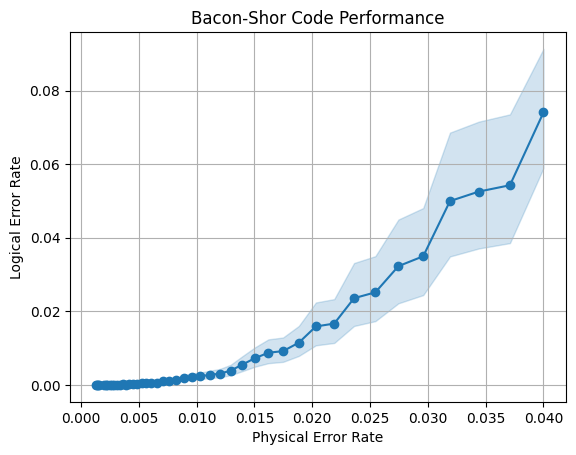

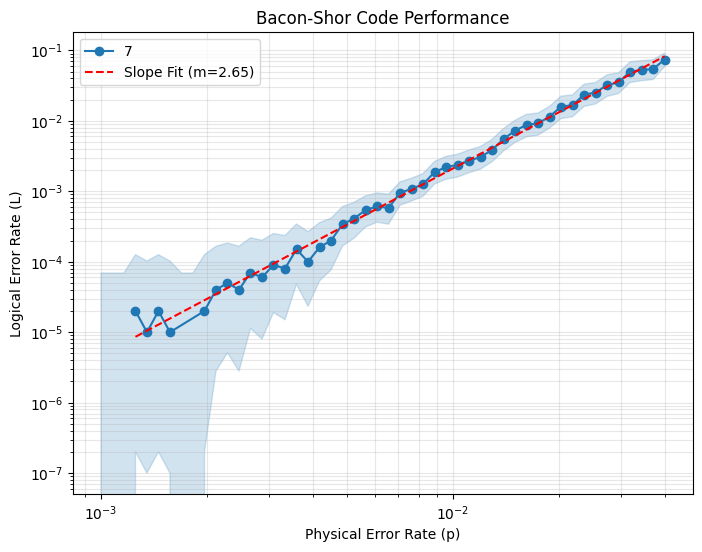

Calculated Slope: 2.6473


In [6]:
ps = np.logspace(np.log10(0.001), np.log10(0.04), 50)
tasks = [
    sinter.Task(
        circuit=bacon_shor_circuit(d=7, p=p),
        json_metadata={'p': p, 'd': 7}
    )
    for p in ps
]

# Run the collection
stats = sinter.collect(
    num_workers=4,
    tasks=tasks,
    decoders=['pymatching'],
    max_shots=100_000,
    max_errors=100,
)
for stat in stats:
    print(f"p={stat.json_metadata['p']}, errors={stat.errors}, rate={stat.errors/stat.shots}")

fig, ax = plt.subplots(1, 1)
sinter.plot_error_rate(
    ax=ax,
    stats=stats,
    x_func=lambda stat: stat.json_metadata['p'],
    group_func=lambda stat: stat.json_metadata['d'],
)
ax.set_title("Bacon-Shor Code Performance")
ax.set_xlabel("Physical Error Rate")
ax.set_ylabel("Logical Error Rate")
ax.grid(True)
plt.show()

xs = np.array([s.json_metadata['p'] for s in stats])
ys = np.array([s.errors / s.shots for s in stats])

# Filter out points with 0 errors (log doesn't like zero)
mask = (ys > 0)
log_p = np.log10(xs[mask])
log_L = np.log10(ys[mask])

# Linear regression: log(L) = slope * log(p) + intercept
slope, intercept, r_value, _, _ = linregress(log_p, log_L)

# --- 4. Plotting ---
fig, ax = plt.subplots(1, 1, figsize=(8, 6))

# Use sinter's plotter for the points
sinter.plot_error_rate(
    ax=ax,
    stats=stats,
    x_func=lambda s: s.json_metadata['p'],
    group_func=lambda s: s.json_metadata['d'],
)

# Plot the fitted slope line
fit_x = np.linspace(min(xs[mask]), max(xs[mask]), 100)
fit_y = 10**(slope * np.log10(fit_x) + intercept)
ax.plot(fit_x, fit_y, 'r--', label=f'Slope Fit (m={slope:.2f})')

ax.set_title("Bacon-Shor Code Performance")
ax.set_xlabel("Physical Error Rate (p)")
ax.set_ylabel("Logical Error Rate (L)")
ax.set_xscale('log')
ax.set_yscale('log')
ax.legend()
ax.grid(True, which="both", ls="-", alpha=0.3)
plt.show()

print(f"Calculated Slope: {slope:.4f}")

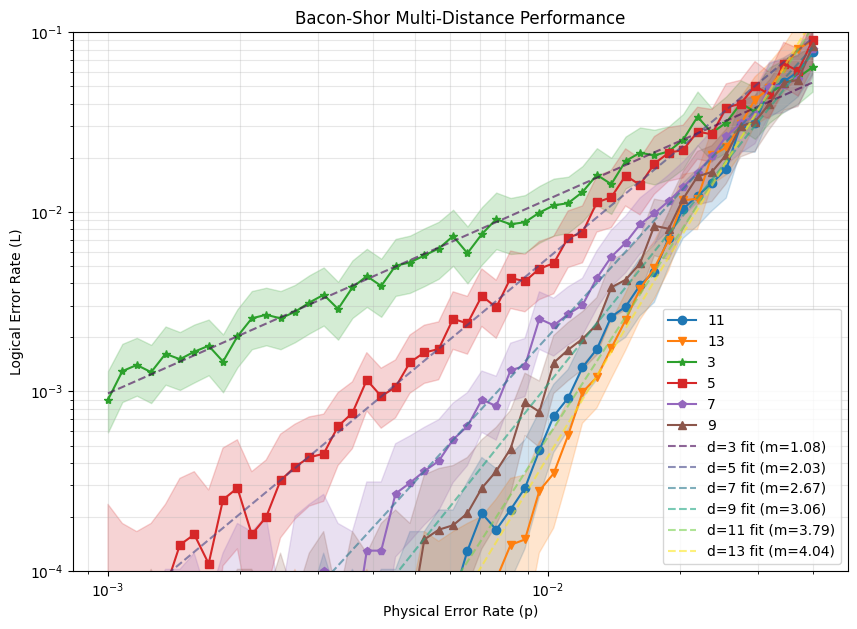

In [ ]:
ps = np.logspace(np.log10(0.001), np.log10(0.04), 50)
distances = [3, 5, 7, 9, 11, 13]
tasks = [
    sinter.Task(
        circuit=bacon_shor_circuit(d=d, p=p),
        json_metadata={'p': p, 'd': d}
    )
    for p in ps
    for d in distances
]

# 2. Run the collection
stats = sinter.collect(
    num_workers=4,
    tasks=tasks,
    decoders=['pymatching'],
    max_shots=100_000,
    max_errors=100,
)

# 3. Plotting with multiple slopes
fig, ax = plt.subplots(1, 1, figsize=(10, 7))

# Sinter handles the multi-distance scatter plotting automatically
sinter.plot_error_rate(
    ax=ax,
    stats=stats,
    x_func=lambda s: s.json_metadata['p'],
    group_func=lambda s: s.json_metadata['d'],
)

# 4. Manually add a slope line for each distance
colors = plt.cm.viridis(np.linspace(0, 1, len(distances)))

for i, d in enumerate(distances):
    # Filter stats for this specific distance
    d_stats = [s for s in stats if s.json_metadata['d'] == d]
    xs = np.array([s.json_metadata['p'] for s in d_stats])
    ys = np.array([s.errors / s.shots for s in d_stats])
    
    # Fit logic
    mask = (ys > 0)
    if not any(mask): continue
    
    log_p = np.log10(xs[mask])
    log_L = np.log10(ys[mask])
    slope, intercept, _, _, _ = linregress(log_p, log_L)
    
    # Plot the fit line
    fit_x = np.linspace(min(xs[mask]), max(xs[mask]), 100)
    fit_y = 10**(slope * np.log10(fit_x) + intercept)
    ax.plot(fit_x, fit_y, '--', color=colors[i], alpha=0.6, 
            label=f'd={d} fit (m={slope:.2f})')

ax.set_title("Bacon-Shor Multi-Distance Performance")
ax.set_xlabel("Physical Error Rate (p)")
ax.set_ylabel("Logical Error Rate (L)")
ax.set_xscale('log')
ax.set_yscale('log')
ax.set_ylim(1e-4,1e-1)
ax.legend()
ax.grid(True, which="both", ls="-", alpha=0.3)
plt.show()

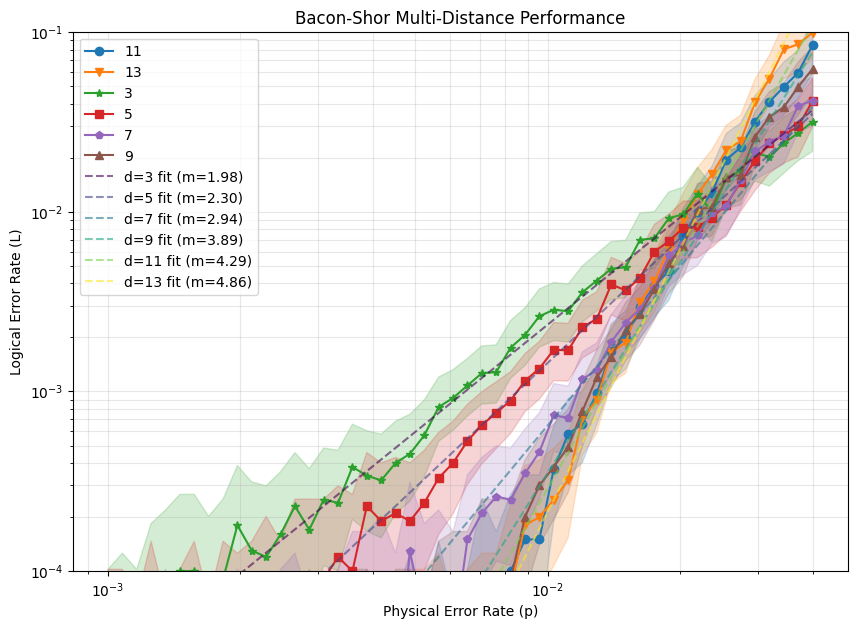

In [14]:
ps = np.logspace(np.log10(0.001), np.log10(0.04), 50)
distances = [3, 5, 7, 9, 11, 13]
tasks = [
    sinter.Task(
        circuit=bacon_shor_circuit(d=d, p=p),
        json_metadata={'p': p, 'd': d}
    )
    for p in ps
    for d in distances
]

# 2. Run the collection
stats = sinter.collect(
    num_workers=4,
    tasks=tasks,
    decoders=['pymatching'],
    max_shots=100_000,
    max_errors=100,
)

# 3. Plotting with multiple slopes
fig, ax = plt.subplots(1, 1, figsize=(10, 7))

# Sinter handles the multi-distance scatter plotting automatically
sinter.plot_error_rate(
    ax=ax,
    stats=stats,
    x_func=lambda s: s.json_metadata['p'],
    group_func=lambda s: s.json_metadata['d'],
)

# 4. Manually add a slope line for each distance
colors = plt.cm.viridis(np.linspace(0, 1, len(distances)))

for i, d in enumerate(distances):
    # Filter stats for this specific distance
    d_stats = [s for s in stats if s.json_metadata['d'] == d]
    xs = np.array([s.json_metadata['p'] for s in d_stats])
    ys = np.array([s.errors / s.shots for s in d_stats])
    
    # Fit logic
    mask = (ys > 0)
    if not any(mask): continue
    
    log_p = np.log10(xs[mask])
    log_L = np.log10(ys[mask])
    slope, intercept, _, _, _ = linregress(log_p, log_L)
    
    # Plot the fit line
    fit_x = np.linspace(min(xs[mask]), max(xs[mask]), 100)
    fit_y = 10**(slope * np.log10(fit_x) + intercept)
    ax.plot(fit_x, fit_y, '--', color=colors[i], alpha=0.6, 
            label=f'd={d} fit (m={slope:.2f})')

ax.set_title("Bacon-Shor Multi-Distance Performance")
ax.set_xlabel("Physical Error Rate (p)")
ax.set_ylabel("Logical Error Rate (L)")
ax.set_xscale('log')
ax.set_yscale('log')
ax.set_ylim(1e-4,1e-1)
ax.legend()
ax.grid(True, which="both", ls="-", alpha=0.3)
plt.show()

In [3]:
circuit = bacon_shor_circuit(d=5, p=0.01)
model = circuit.detector_error_model(decompose_errors=True)
matching = pymatching.Matching.from_detector_error_model(model)

In [4]:
sampler = circuit.compile_detector_sampler()
syndrome, actual_observables = sampler.sample(shots=1000, separate_observables=True)

In [5]:
predicted_observables = matching.decode_batch(syndrome)
num_errors = np.sum(np.any(predicted_observables != actual_observables, axis=1))

In [6]:
print(num_errors) 

0


In [7]:
matching_corr = pymatching.Matching.from_detector_error_model(model, enable_correlations=True)

In [8]:
predicted_observables_corr = matching_corr.decode_batch(syndrome, enable_correlations=True)
num_errors = np.sum(np.any(predicted_observables_corr != actual_observables, axis=1))

print(num_errors)  

0


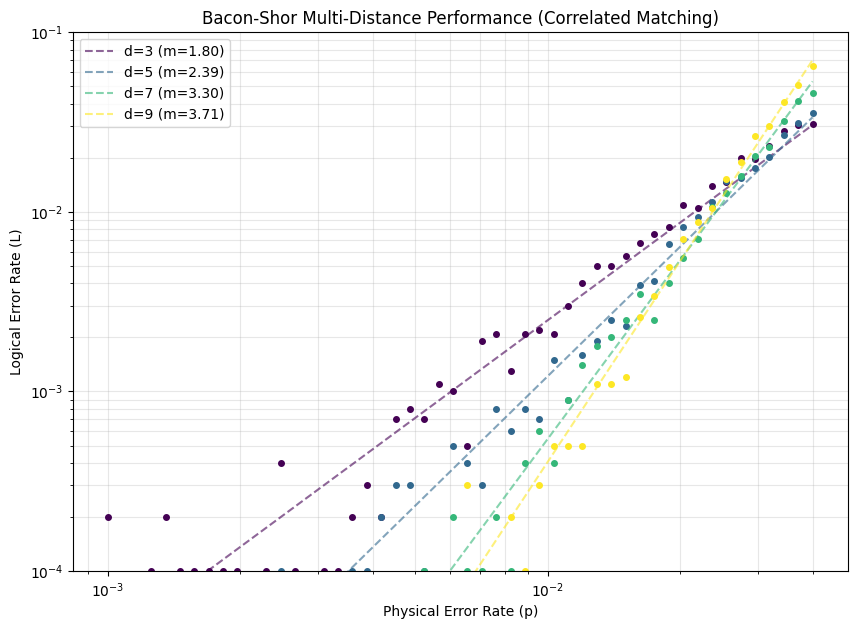

In [20]:
# 1. Configuration
distances = [3, 5,7,9]
ps = np.logspace(np.log10(0.001), np.log10(0.04), 50) # 10 points for speed, increase to 50 for final
shots = 10000 

fig, ax = plt.subplots(1, 1, figsize=(10, 7))
colors = plt.cm.viridis(np.linspace(0, 1, len(distances)))

# 2. Main Loop
for i, d in enumerate(distances):
    xs = []
    ys = []
    
    for p in ps:
        # Generate circuit and model
        circuit = bacon_shor_circuit(d, p)
        model = circuit.detector_error_model(decompose_errors=True)
        
        # Setup Sampler
        sampler = circuit.compile_detector_sampler()
        syndrome, actual_obs = sampler.sample(shots=shots, separate_observables=True)
        
        # Setup Correlated Decoder
        # NOTE: enable_correlations=True must be in both places!
        matching = pymatching.Matching.from_detector_error_model(model, enable_correlations=True)
        predicted_obs = matching.decode_batch(syndrome, enable_correlations=True)
        
        # Calculate rates
        num_errors = np.sum(np.any(predicted_obs != actual_obs, axis=1))
        
        xs.append(p)
        ys.append(num_errors / shots)
    
    xs = np.array(xs)
    ys = np.array(ys)
    
    # # 3. Plotting Points (Mimicking sinter's style)
    ax.plot(xs, ys, 'o', color=colors[i], markersize=4)

    # # 1. Calculate the Standard Error for the Shading
    # # Standard deviation of a binomial distribution: sqrt(p(1-p)/n)
    # stderrs = np.sqrt(ys * (1 - ys) / shots)

    # # 2. Plotting with Shading
    # ax.plot(xs, ys, 'o', color=colors[i], markersize=4)
    # # The Shading: ys +/- 1 standard error
    # ax.fill_between(xs, ys - stderrs, ys + stderrs, color=colors[i], alpha=0.2)
    
    # 4. Slope Fitting Logic
    mask = ys > 0
    if np.any(mask):
        log_p = np.log10(xs[mask])
        log_L = np.log10(ys[mask])
        slope, intercept, _, _, _ = linregress(log_p, log_L)
        
        # Plot the fit line
        fit_x = np.linspace(min(xs[mask]), max(xs[mask]), 100)
        fit_y = 10**(slope * np.log10(fit_x) + intercept)
        ax.plot(fit_x, fit_y, '--', color=colors[i], alpha=0.6, 
                label=f'd={d} (m={slope:.2f})')

# 5. Styling (Matching your requested code)
ax.set_title("Bacon-Shor Multi-Distance Performance (Correlated Matching)")
ax.set_xlabel("Physical Error Rate (p)")
ax.set_ylabel("Logical Error Rate (L)")
ax.set_xscale('log')
ax.set_yscale('log')
ax.set_ylim(1e-4, 1e-1) # As requested
ax.legend()
ax.grid(True, which="both", ls="-", alpha=0.3)

plt.show()

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import linregress
import pymatching
import stim
import sinter

distances = [3,5,7]
ps = np.logspace(np.log10(0.001), np.log10(0.04), 200)
shots = 10000

# --- PART 1: Run Standard Matching with SINTER ---
tasks = [
    sinter.Task(circuit=bacon_shor_circuit(d, p), json_metadata={'d': d, 'p': p})
    for d in distances for p in ps
]

stats = sinter.collect(
    num_workers=4,
    tasks=tasks,
    decoders=['pymatching'], # Standard sinter call
    max_shots=shots
)

# --- PART 2: Run Correlated Matching MANUALLY ---
# We store these in a dictionary: {distance: [rates]}
manual_results = {d: [] for d in distances}

for d in distances:
    print(f"Manually decoding d={d} with correlations...")
    for p in ps:
        circuit = bacon_shor_circuit(d, p)
        model = circuit.detector_error_model(decompose_errors=True)
        sampler = circuit.compile_detector_sampler()
        syndrome, actual_obs = sampler.sample(shots=shots, separate_observables=True)
        
        # Manual Correlated Matching
        m = pymatching.Matching.from_detector_error_model(model, enable_correlations=True)
        pred = m.decode_batch(syndrome, enable_correlations=True)
        
        err_rate = np.sum(np.any(pred != actual_obs, axis=1)) / shots
        manual_results[d].append(err_rate)



Manually decoding d=3 with correlations...
Manually decoding d=5 with correlations...
Manually decoding d=7 with correlations...


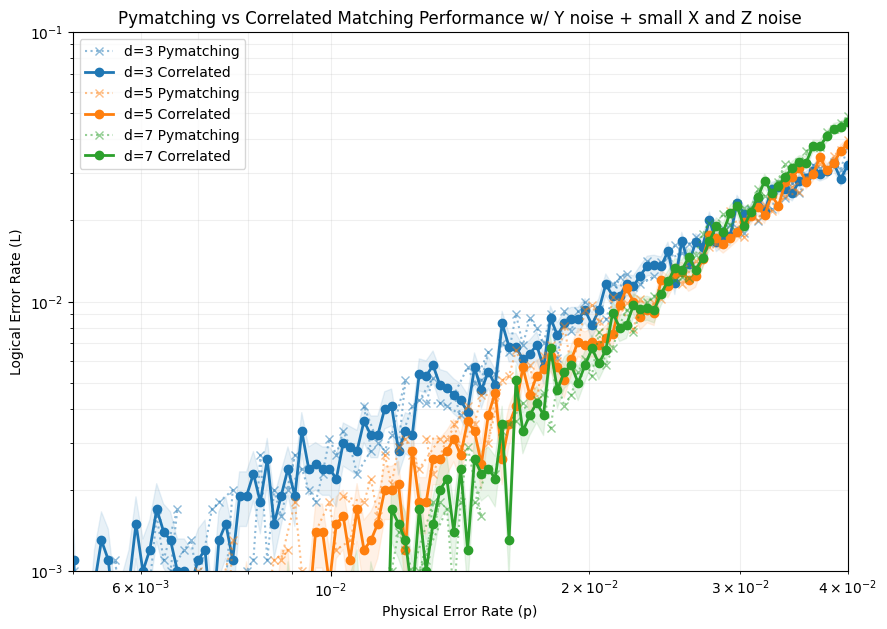

In [3]:
# --- PART 3: Combined Plotting ---
fig, ax = plt.subplots(1, 1, figsize=(10, 7))
colors = ['#1f77b4', '#ff7f0e', '#2ca02c']

for i, d in enumerate(distances):
    # A. Plot Sinter Data (Standard)
    d_stats = [s for s in stats if s.json_metadata['d'] == d]
    s_xs = np.array([s.json_metadata['p'] for s in d_stats])
    s_ys = np.array([s.errors / s.shots for s in d_stats])
    ax.plot(s_xs, s_ys, 'x:', color=colors[i], alpha=0.5, label=f'd={d} Pymatching')

    # B. Plot Manual Data (Correlated)
    m_ys = np.array(manual_results[d])
    ax.plot(ps, m_ys, 'o-', color=colors[i], linewidth=2, label=f'd={d} Correlated')

    # C. Add shading for the manual data
    stderrs = np.sqrt(m_ys * (1 - m_ys) / shots)
    ax.fill_between(ps, m_ys - stderrs, m_ys + stderrs, color=colors[i], alpha=0.1)

ax.set_title("Pymatching vs Correlated Matching Performance w/ Y noise + small X and Z noise")
ax.set_xlabel("Physical Error Rate (p)")
ax.set_ylabel("Logical Error Rate (L)")
ax.set_xscale('log')
ax.set_yscale('log')
ax.set_ylim(1e-3, 1e-1)
ax.set_xlim(5e-3, 0.04)
ax.legend(loc='best')
ax.grid(True, which="both", ls="-", alpha=0.2)
plt.show()

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import linregress
import pymatching
import stim
import sinter

distances = [3,5,7]
ps = np.logspace(np.log10(0.001), np.log10(0.04), 200)
shots = 10000

# --- PART 1: Run Standard Matching with SINTER ---
tasks = [
    sinter.Task(circuit=bacon_shor_circuit(d, p), json_metadata={'d': d, 'p': p})
    for d in distances for p in ps
]

stats = sinter.collect(
    num_workers=4,
    tasks=tasks,
    decoders=['pymatching'], # Standard sinter call
    max_shots=shots
)

# --- PART 2: Run Correlated Matching MANUALLY ---
# We store these in a dictionary: {distance: [rates]}
manual_results = {d: [] for d in distances}

for d in distances:
    print(f"Manually decoding d={d} with correlations...")
    for p in ps:
        circuit = bacon_shor_circuit(d, p)
        model = circuit.detector_error_model(decompose_errors=True)
        sampler = circuit.compile_detector_sampler()
        syndrome, actual_obs = sampler.sample(shots=shots, separate_observables=True)
        
        # Manual Correlated Matching
        m = pymatching.Matching.from_detector_error_model(model, enable_correlations=True)
        pred = m.decode_batch(syndrome, enable_correlations=True)
        
        err_rate = np.sum(np.any(pred != actual_obs, axis=1)) / shots
        manual_results[d].append(err_rate)



Manually decoding d=3 with correlations...
Manually decoding d=5 with correlations...
Manually decoding d=7 with correlations...


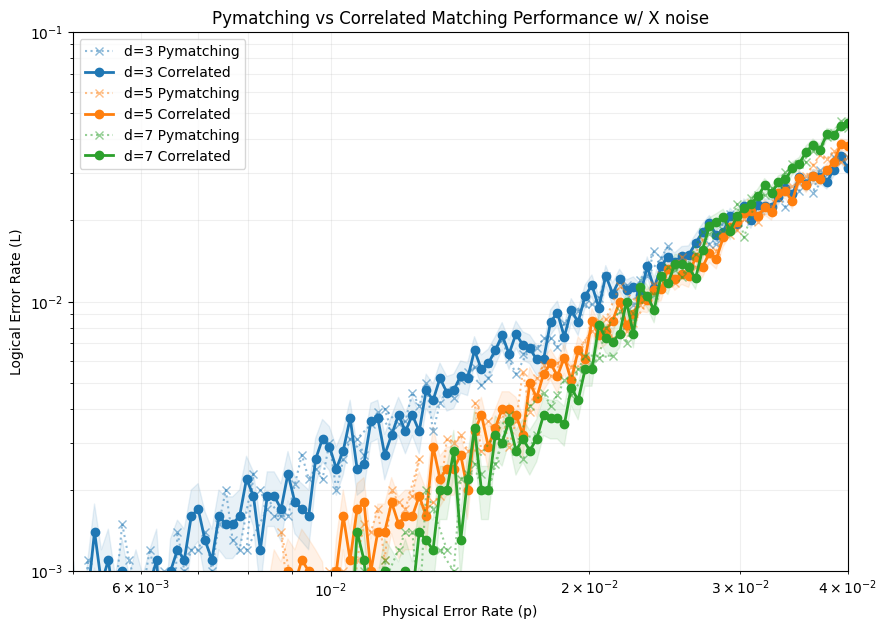

In [3]:
# --- PART 3: Combined Plotting ---
fig, ax = plt.subplots(1, 1, figsize=(10, 7))
colors = ['#1f77b4', '#ff7f0e', '#2ca02c']

for i, d in enumerate(distances):
    # A. Plot Sinter Data (Standard)
    d_stats = [s for s in stats if s.json_metadata['d'] == d]
    s_xs = np.array([s.json_metadata['p'] for s in d_stats])
    s_ys = np.array([s.errors / s.shots for s in d_stats])
    ax.plot(s_xs, s_ys, 'x:', color=colors[i], alpha=0.5, label=f'd={d} Pymatching')

    # B. Plot Manual Data (Correlated)
    m_ys = np.array(manual_results[d])
    ax.plot(ps, m_ys, 'o-', color=colors[i], linewidth=2, label=f'd={d} Correlated')

    # C. Add shading for the manual data
    stderrs = np.sqrt(m_ys * (1 - m_ys) / shots)
    ax.fill_between(ps, m_ys - stderrs, m_ys + stderrs, color=colors[i], alpha=0.1)

ax.set_title("Pymatching vs Correlated Matching Performance w/ X noise")
ax.set_xlabel("Physical Error Rate (p)")
ax.set_ylabel("Logical Error Rate (L)")
ax.set_xscale('log')
ax.set_yscale('log')
ax.set_ylim(1e-3, 1e-1)
ax.set_xlim(5e-3, 0.04)
ax.legend(loc='best')
ax.grid(True, which="both", ls="-", alpha=0.2)
plt.show()

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import linregress
import pymatching
import stim
import sinter

distances = [3,5,7]
ps = np.logspace(np.log10(0.001), np.log10(0.04), 200)
shots = 10000

# --- PART 1: Run Standard Matching with SINTER ---
tasks = [
    sinter.Task(circuit=bacon_shor_circuit(d, p), json_metadata={'d': d, 'p': p})
    for d in distances for p in ps
]

stats = sinter.collect(
    num_workers=4,
    tasks=tasks,
    decoders=['pymatching'], # Standard sinter call
    max_shots=shots
)

# --- PART 2: Run Correlated Matching MANUALLY ---
# We store these in a dictionary: {distance: [rates]}
manual_results = {d: [] for d in distances}

for d in distances:
    print(f"Manually decoding d={d} with correlations...")
    for p in ps:
        circuit = bacon_shor_circuit(d, p)
        model = circuit.detector_error_model(decompose_errors=True)
        sampler = circuit.compile_detector_sampler()
        syndrome, actual_obs = sampler.sample(shots=shots, separate_observables=True)
        
        # Manual Correlated Matching
        m = pymatching.Matching.from_detector_error_model(model, enable_correlations=True)
        pred = m.decode_batch(syndrome, enable_correlations=True)
        
        err_rate = np.sum(np.any(pred != actual_obs, axis=1)) / shots
        manual_results[d].append(err_rate)

Manually decoding d=3 with correlations...
Manually decoding d=5 with correlations...
Manually decoding d=7 with correlations...


d=3 Correlated Rates: [0.     0.     0.     0.0002 0.     0.     0.     0.     0.     0.
 0.     0.     0.     0.0001 0.     0.     0.0001 0.0001 0.     0.
 0.0001 0.0001 0.0001 0.     0.     0.     0.0002 0.     0.     0.0001
 0.     0.0001 0.     0.0002 0.0003 0.0003 0.0001 0.0002 0.0001 0.0003
 0.0001 0.0001 0.0001 0.     0.0005 0.     0.     0.     0.     0.0001
 0.     0.0004 0.0002 0.0001 0.0001 0.0001 0.0004 0.0003 0.0003 0.0003
 0.0001 0.0002 0.0001 0.0002 0.0004 0.0001 0.0004 0.0005 0.0006 0.0004
 0.0001 0.0005 0.0005 0.0004 0.0004 0.0006 0.0004 0.0006 0.0005 0.0005
 0.0007 0.0006 0.0005 0.0008 0.0012 0.0007 0.0006 0.0003 0.0013 0.0011
 0.0003 0.0005 0.0003 0.0007 0.0006 0.0005 0.0009 0.0011 0.0002 0.0013
 0.001  0.0012 0.0008 0.001  0.0009 0.0016 0.001  0.0011 0.0018 0.0012
 0.0015 0.0013 0.0016 0.0013 0.0014 0.0011 0.002  0.0026 0.0022 0.0022
 0.0026 0.003  0.0031 0.0022 0.0021 0.0028 0.0023 0.0024 0.0027 0.0031
 0.0035 0.0025 0.0036 0.0051 0.0038 0.0036 0.0031 0.0039 0.0038

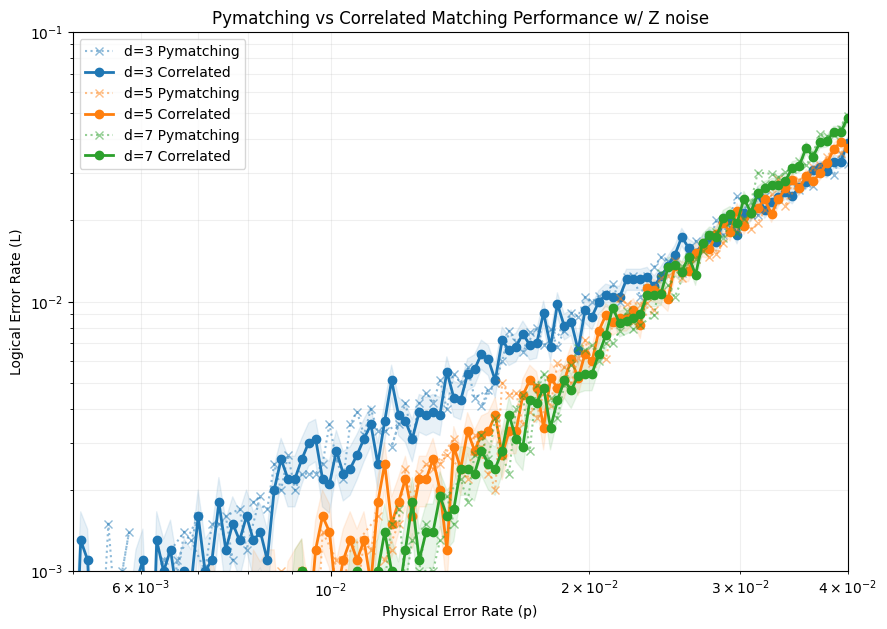

In [8]:
# --- PART 3: Combined Plotting ---
fig, ax = plt.subplots(1, 1, figsize=(10, 7))
colors = ['#1f77b4', '#ff7f0e', '#2ca02c']

for i, d in enumerate(distances):
    # A. Plot Sinter Data (Standard)
    d_stats = [s for s in stats if s.json_metadata['d'] == d]
    s_xs = np.array([s.json_metadata['p'] for s in d_stats])
    s_ys = np.array([s.errors / s.shots for s in d_stats])
    ax.plot(s_xs, s_ys, 'x:', color=colors[i], alpha=0.5, label=f'd={d} Pymatching')

    # B. Plot Manual Data (Correlated)
    m_ys = np.array(manual_results[d])
    print(f"d={d} Correlated Rates: {m_ys}")
    ax.plot(ps, m_ys, 'o-', color=colors[i], linewidth=2, label=f'd={d} Correlated')

    # C. Add shading for the manual data
    stderrs = np.sqrt(m_ys * (1 - m_ys) / shots)
    ax.fill_between(ps, m_ys - stderrs, m_ys + stderrs, color=colors[i], alpha=0.1)

ax.set_title("Pymatching vs Correlated Matching Performance w/ Z noise")
ax.set_xlabel("Physical Error Rate (p)")
ax.set_ylabel("Logical Error Rate (L)")
ax.set_xscale('log')
ax.set_yscale('log')
ax.set_ylim(1e-3, 1e-1)
ax.set_xlim(5e-3, 0.04)
ax.legend(loc='best')
ax.grid(True, which="both", ls="-", alpha=0.2)
plt.show()

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import linregress
import pymatching
import stim
import sinter
from stim_baconshor import *

distances = [3,5,7]
ps = np.logspace(np.log10(0.001), np.log10(0.04), 200)
shots = 10000

# --- PART 1: Run Standard Matching with SINTER ---
tasks = [
    sinter.Task(circuit=bacon_shor_circuit(d, p), json_metadata={'d': d, 'p': p})
    for d in distances for p in ps
]

stats = sinter.collect(
    num_workers=4,
    tasks=tasks,
    decoders=['pymatching'], # Standard sinter call
    max_shots=shots
)

# --- PART 2: Run Correlated Matching MANUALLY ---
# We store these in a dictionary: {distance: [rates]}
manual_results = {d: [] for d in distances}

for d in distances:
    print(f"Manually decoding d={d} with correlations...")
    base_circuit = bacon_shor_circuit(d, 0.01)
    model = base_circuit.detector_error_model(decompose_errors=True, approximate_disjoint_errors=True)
    m = pymatching.Matching.from_detector_error_model(model, enable_correlations=True)
    for p in ps:
        circuit = bacon_shor_circuit(d, p)
        sampler = circuit.compile_detector_sampler()
        syndrome, actual_obs = sampler.sample(shots=shots, separate_observables=True)
        
        # Manual Correlated Matching
        
        pred = m.decode_batch(syndrome, enable_correlations=True)
        
        err_rate = np.sum(np.any(pred != actual_obs, axis=1)) / shots
        manual_results[d].append(err_rate)

Manually decoding d=3 with correlations...
Manually decoding d=5 with correlations...
Manually decoding d=7 with correlations...


d=3 Correlated Rates: [0.     0.     0.0002 0.0001 0.     0.     0.0001 0.     0.0001 0.
 0.     0.0001 0.0001 0.     0.     0.0001 0.0001 0.     0.     0.
 0.     0.     0.0002 0.0004 0.     0.0001 0.0001 0.0001 0.0001 0.0001
 0.     0.0002 0.0001 0.0001 0.     0.     0.0003 0.0001 0.0001 0.0001
 0.     0.0005 0.     0.0001 0.0001 0.     0.0004 0.0001 0.     0.0002
 0.0002 0.0002 0.0001 0.0005 0.0001 0.0002 0.0001 0.0003 0.0003 0.0001
 0.0001 0.0004 0.     0.0003 0.0001 0.0003 0.0007 0.0004 0.0006 0.0008
 0.0002 0.0008 0.0003 0.0004 0.0002 0.0002 0.     0.0004 0.0006 0.0008
 0.0005 0.0005 0.0005 0.0006 0.0009 0.0005 0.0004 0.0009 0.0005 0.001
 0.0004 0.0009 0.0004 0.0003 0.0012 0.001  0.0008 0.0013 0.001  0.0019
 0.0005 0.0011 0.0012 0.0012 0.001  0.0014 0.001  0.0017 0.0017 0.0017
 0.0018 0.0022 0.0014 0.0013 0.0024 0.0019 0.002  0.0025 0.0016 0.002
 0.0026 0.0021 0.0028 0.0022 0.0026 0.0024 0.0026 0.0035 0.0034 0.0033
 0.0037 0.0037 0.0028 0.0037 0.0026 0.0045 0.0041 0.0037 0.0037 0

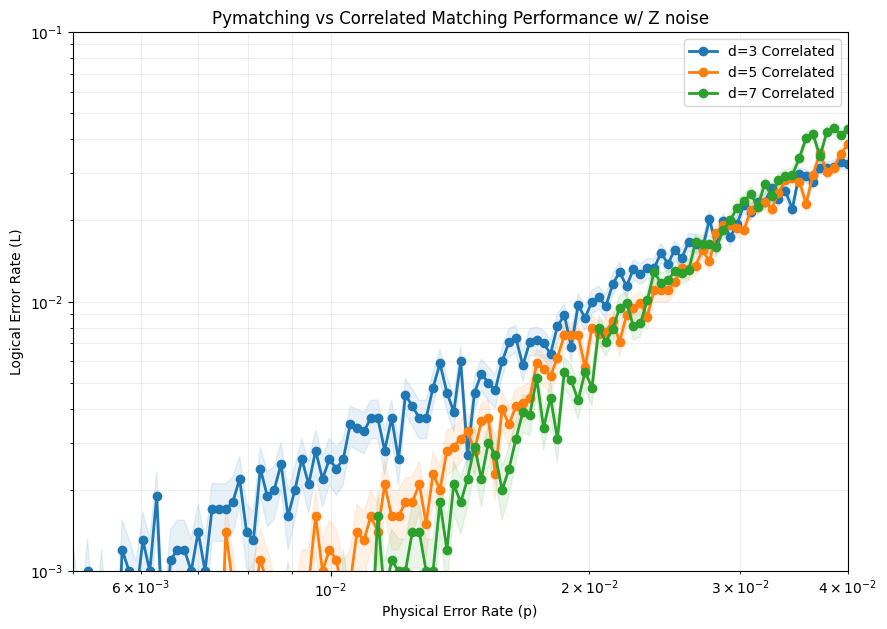

In [3]:
# --- PART 3: Combined Plotting ---
fig, ax = plt.subplots(1, 1, figsize=(10, 7))
colors = ['#1f77b4', '#ff7f0e', '#2ca02c']

for i, d in enumerate(distances):
    # B. Plot Manual Data (Correlated)
    m_ys = np.array(manual_results[d])
    print(f"d={d} Correlated Rates: {m_ys}")
    ax.plot(ps, m_ys, 'o-', color=colors[i], linewidth=2, label=f'd={d} Correlated')

    # C. Add shading for the manual data
    stderrs = np.sqrt(m_ys * (1 - m_ys) / shots)
    ax.fill_between(ps, m_ys - stderrs, m_ys + stderrs, color=colors[i], alpha=0.1)

ax.set_title("Pymatching vs Correlated Matching Performance w/ Z noise")
ax.set_xlabel("Physical Error Rate (p)")
ax.set_ylabel("Logical Error Rate (L)")
ax.set_xscale('log')
ax.set_yscale('log')
ax.set_ylim(1e-3, 1e-1)
ax.set_xlim(5e-3, 0.04)
ax.legend(loc='best')
ax.grid(True, which="both", ls="-", alpha=0.2)
plt.show()

### Detector Error Model for Pymatching

In [2]:
circuit = bacon_shor_circuit(3, 0.1)
model = circuit.detector_error_model(decompose_errors=True)
model

stim.DetectorErrorModel('''
    error(3e-07) D0 D1
    error(0.1) D0 D1 ^ D2
    error(0.1) D0 D1 ^ D2 D3
    error(0.1) D0 D1 ^ D3
    error(0.1) D0 D2 L0
    error(0.1) D0 D2 L0 ^ D3
    error(0.1) D0 D3 L0
    error(3e-07) D0 L0
    error(3e-07) D1
    error(0.1) D1 D2
    error(0.1) D1 D2 ^ D3
    error(0.1) D1 D3
    error(3e-07) D2
    error(3e-07) D2 D3
    error(3e-07) D3
    detector(2.5, 1.5, 0) D0
    detector(2.5, 1.5, 0) D1
    detector(0.5, 1.5, 0) D2
    detector(1.5, 1.5, 0) D3
''')

In [3]:
circuit = bacon_shor_circuit(5, 0.1)
model = circuit.detector_error_model(decompose_errors=True)
model

stim.DetectorErrorModel('''
    error(5e-07) D0 D1
    error(0.1) D0 D1 ^ D4
    error(0.1) D0 D1 ^ D4 D5
    error(0.1) D0 D1 ^ D5 D6
    error(0.1) D0 D1 ^ D6 D7
    error(0.1) D0 D1 ^ D7
    error(0.1) D0 D4 L0
    error(0.1) D0 D7 L0
    error(5e-07) D0 L0
    error(0.1) D0 L0 ^ D4 D5
    error(0.1) D0 L0 ^ D5 D6
    error(0.1) D0 L0 ^ D6 D7
    error(5e-07) D1 D2
    error(0.1) D1 D2 ^ D4
    error(0.1) D1 D2 ^ D4 D5
    error(0.1) D1 D2 ^ D5 D6
    error(0.1) D1 D2 ^ D6 D7
    error(0.1) D1 D2 ^ D7
    error(5e-07) D2 D3
    error(0.1) D2 D3 ^ D4
    error(0.1) D2 D3 ^ D4 D5
    error(0.1) D2 D3 ^ D5 D6
    error(0.1) D2 D3 ^ D6 D7
    error(0.1) D2 D3 ^ D7
    error(5e-07) D3
    error(0.1) D3 D4
    error(0.1) D3 D7
    error(0.1) D3 ^ D4 D5
    error(0.1) D3 ^ D5 D6
    error(0.1) D3 ^ D6 D7
    error(5e-07) D4
    error(5e-07) D4 D5
    error(5e-07) D5 D6
    error(5e-07) D6 D7
    error(5e-07) D7
    detector(4.5, 2.5, 0) D0
    detector(4.5, 2.5, 0) D1
    detector(4.5, 2.5

In [4]:
from paritymatchingstatic import *
from stim_baconshor import *
import stim

In [7]:
circuit = bacon_shor_circuit(3, 0.1)
edge_map = edge_coordinate_map(circuit)
# print(edge_map)
x_edges, z_edges = matching(circuit)
print("X edges:", x_edges)
print("Z edges:", z_edges)
# z_error_locations, x_error_locations = get_locations_from_edges(circuit, x_edges, z_edges)
# print("Z error locations:", z_error_locations)
# print("X error locations:", x_error_locations)
# intersection(z_error_locations, x_error_locations)

X edges: [[ 0  1]
 [ 3 -1]]
Z edges: [[ 0  1]
 [ 3 -1]]


In [6]:
edge_map

{0: [(2.0, 1.0, 0.0)],
 1: [(0.0, 1.0, 0.0)],
 2: [(1.0, 1.0, 0.0)],
 3: [(2.0, 1.0, 0.0)],
 4: [(1.0, 0.0, 0.0)],
 5: [(0.0, 0.0, 0.0)],
 6: [(2.0, 0.0, 0.0)],
 7: [(2.0, 0.0, 0.0)],
 8: [(2.0, 2.0, 0.0)],
 9: [(0.0, 2.0, 0.0)],
 10: [(1.0, 2.0, 0.0)],
 11: [(2.0, 2.0, 0.0)],
 12: [(0.0, 2.0, 0.0)],
 13: [(1.0, 2.0, 0.0)],
 14: [(2.0, 2.0, 0.0)]}

In [8]:
explained_errors = circuit.explain_detector_error_model_errors()

In [9]:
explained_errors

[stim.ExplainedError(dem_error_terms=(stim.DemTargetWithCoords(dem_target=stim.DemTarget('D0'), coords=[2.5, 1.5, 0]),stim.DemTargetWithCoords(dem_target=stim.DemTarget('D1'), coords=[2.5, 1.5, 0]),), circuit_error_locations=(stim.CircuitErrorLocation(tick_offset=5, flipped_pauli_product=(stim.GateTargetWithCoords(stim.target_x(5), [2, 1, 0]),), flipped_measurement=stim.FlippedMeasurement(
     record_index=None,
     observable=(),
 ), instruction_targets=stim.CircuitTargetsInsideInstruction(gate='X_ERROR', args=[1e-07], target_range_start=0, target_range_end=1, targets_in_range=(stim.GateTargetWithCoords(5, [2, 1, 0]),)), stack_frames=(stim.CircuitErrorLocationStackFrame(
     instruction_offset=35,
     iteration_index=0,
     instruction_repetitions_arg=0,
 ),)),stim.CircuitErrorLocation(tick_offset=5, flipped_pauli_product=(stim.GateTargetWithCoords(stim.target_x(4), [1, 1, 0]),), flipped_measurement=stim.FlippedMeasurement(
     record_index=None,
     observable=(),
 ), instruct

## Plots for march meeting

In [ ]:
distances=[3,5,9,13]
ps=[0.002,0.003, 0.005, 0.008, 0.01, 0.015, 0.02, 0.03, 0.04,0.05]
tasks = [
    sinter.Task(
        circuit=bacon_shor_circuit(d=d, p=p),
        json_metadata={'p': p, 'd': d}
    )
    for p in ps
    for d in distances
]

# 2. Run the collection
stats = sinter.collect(
    num_workers=4,
    tasks=tasks,
    decoders=['pymatching'],
    max_shots=500_000,
    max_errors=100,
)

In [7]:
filename = "pymatchingplotdata.txt"
with open(filename, "a") as file:
    for s in stats:
        # Extract metadata we stored in the tasks
        d = s.json_metadata['d']
        p = s.json_metadata['p']
        
        # Sinter calls errors 'errors' and total trials 'shots'
        count = s.errors
        shots = s.shots
        
        # Print in the exact space-separated format you use for MLE
        print(d, p, count, shots, sep=" ", file=file)

print(f"Sinter results saved to {filename}")

Sinter results saved to pymatchingplotdata.txt


In [8]:
import numpy as np
import matplotlib.pyplot as plt

def print_from_csv(title):
    # Format: Distance, Phys_Prob, Count, Shots
    data = {}
    
    with open(title, "r") as f:
        for line in f:
            parts = line.strip().split()
            if not parts: continue
            
            d = int(parts[0])
            phys = float(parts[1])
            count = int(parts[2])
            shots = int(parts[3])
            
            # Calculate Logical Error Rate and Standard Deviation
            log_rate = count / shots
            # Error bar: sqrt(p(1-p)/n). Use a small floor to avoid 0 for small samples
            std = np.sqrt(log_rate * (1 - log_rate) / shots) if shots > 0 else 0
            
            if d not in data:
                data[d] = []
            data[d].append((phys, log_rate, std))
    
    # Sort by distance, then sort the points for each distance by physical prob
    sorted_distances = sorted(data.keys())
    phys_lists = []
    log_lists = []
    errorbars_list = []
    
    for d in sorted_distances:
        # Sort points by 'phys' so the line plot is continuous
        data[d].sort(key=lambda x: x[0])
        
        phys_lists.append([x[0] for x in data[d]])
        log_lists.append([x[1] for x in data[d]])
        errorbars_list.append([x[2] for x in data[d]])
        
    return phys_lists, log_lists, sorted_distances, errorbars_list

In [11]:
import numpy as np
import matplotlib.pyplot as plt

def plot_multiple(distances, phys_lists, log_lists, low_lim, high_lim, decoder, title="", error_bars=None):
    # Setup figure and axis with high resolution
    fig, ax = plt.subplots(1, 1, dpi=200, figsize=(5.5, 4.5))

    # Define specific styles to match the example image (order matters)
    # The example uses markers: down-triangle, star, square, circle
    styles = [
        {'color': '#ff7f0e', 'marker': 'v', 'markersize': 5, 'label_suffix': 'pymatching'}, # d=3 (typically)
        {'color': '#2ca02c', 'marker': '*', 'markersize': 6, 'label_suffix': 'pymatching'}, # d=5 (typically)
        {'color': '#d62728', 'marker': 's', 'markersize': 5, 'label_suffix': 'pymatching'}, # d=9 (typically)
        {'color': '#1f77b4', 'marker': 'o', 'markersize': 5, 'label_suffix': 'pymatching'}, # d=13 (typically)
    ]

    # Iterate through each distance, applying specific style from list
    # Assuming distances are already sorted: [3, 5, 9, 13]
    for i, d in enumerate(distances):
        p = phys_lists[i]
        l = log_lists[i]
        
        # Get style for this index (cyclical if more than 4 distances)
        style = styles[i % len(styles)]
        
        # Format the label (e.g., "13pymatching") to match example exactly
        legend_label = f"{d}{style['label_suffix']}"

        if error_bars:
            eb = error_bars[i]
            # Use errorbar with style dictionary, adding alpha shading to match example
            eb_artist = ax.errorbar(p, l, yerr=eb, 
                                     fmt=style['marker'], 
                                     color=style['color'], 
                                     markersize=style['markersize'], 
                                     capsize=3, elinewidth=1, 
                                     label=legend_label)
            
            # Match the faint shading from the example
            eb_artist[-1][0].set_alpha(0.15) 
            # Re-draw the connecting line (often errorbar handles this, but let's be safe)
            ax.plot(p, l, color=style['color'], alpha=0.8, linewidth=1)

        else:
            # Simple plot if no error bars
            ax.plot(p, l, 
                    linestyle='-', 
                    marker=style['marker'], 
                    color=style['color'], 
                    markersize=style['markersize'], 
                    alpha=0.8, 
                    label=legend_label)

    # --- Plot Formatting (to match look and feel) ---
    
    # 1. Scale: Standard for threshold plots is log-log
    ax.set_yscale("log")
    ax.set_xscale("log")
    
    # 2. Limits: Use low_lim and high_lim for both x and y
    ax.set_ylim(low_lim, high_lim)
    ax.set_xlim(low_lim, high_lim)
    
    # 3. Grid: Standard light dashed grid
    ax.grid(True, which="both", ls="--", alpha=0.4)
    
    # 4. Labels (slightly customized to match typical QEC layout)
    ax.set_xlabel("Physical Error Rate", fontsize=11)
    ax.set_ylabel("Logical error rate", fontsize=11)
    
    # 5. Legend: Move to BOTTOM-RIGHT, reduce size, and format exactly
    ax.legend(fontsize=8, loc='lower right', frameon=True)
    
    # Optional: Optional Title (often removed for publications)
    if title:
        plt.title(title)
        
    plt.tight_layout()
    plt.show()

In [ ]:
phys, logs, dists, errs = print_from_csv("pymatchingplotdata.txt")

plot_multiple(
    distances=dists, 
    phys_lists=phys, 
    log_lists=logs, 
    low_lim=1e-3, 
    high_lim=1e-1, 
    decoder="MLE", 
    title="Bacon-Shor Code Performance",
    error_bars=errs
)